The marginal PnL gained from 1% of Research or Scale vastly outweighs the fixed 500 XIREC cost of using that budget. \
**Rational players allocate exactly 100% of their budget.**

We allocate $r$ to Research, $s$ to Scale, and $v$ to Speed. Base PnL (before the Speed multiplier) as a function of the remaining budget after allocating $v$ to Speed is:

$$Base(v) = \max_{r+s = 100-v} \left( 200,000 \cdot \frac{\ln(1+r)}{\ln(101)} \cdot 0.07s \right)$$

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
def research(r):  # 0 <= pct_research <= 100
    return 200_000 * np.log(1 + r) / np.log(1 + 100)

In [3]:
def scale(s):  # 0 <= pct_scale <= 100
    return s / 100 * 7

In [4]:
def base(v):
    results = {}
    for r in range(1, 101 - v):  # allocated to research
        s = 100 - v - r  # allocated to scale
        results[(r, s)] = research(r) * scale(s)
    b = max(results.values())
    optimal_pcts = [k for k, v in results.items() if v == b][0]
    return b,  optimal_pcts

In [5]:
bs = []
for v in range(1, 100):
    b, (_, _) = base(v)
    bs.append(b)

In [6]:
base_0, (r, s) = base(0)
print(f"Base(v=0) = {base_0}")
print(f"Gross PnL: {base_0 * 0.1}")
print(f"Net PnL: {base_0 * 0.1 - 50000}")
print('\nOptimal Percentages:')
print(f"Research: {r}")
print(f"Scale: {s}")

Base(v=0) = 742329.9167623717
Gross PnL: 74232.99167623717
Net PnL: 24232.991676237172

Optimal Percentages:
Research: 23
Scale: 77


If we allocate 0% to Speed and accept last place (a 0.1 multiplier), the optimal split for the remaining 100% is 23% Research and 77% Scale and the PnL is **24,233**. \
**This is the absolute floor. It is the guaranteed payout for a rational player who completely opts out of the Speed race.**

Now, how much are we willing to bid on Speed to get the maximum 0.9 multiplier while still matching that 24,233 floor?

$$(Base(v_{max}) \cdot 0.9) - 50,000 = 24,233$$ $$Base(v_{max}) \approx 82,481$$

In [7]:
for r_s in range(1, 101):  # combined r and s
    base_v_max, (r, s) = base(100 - r_s)
    if base_v_max >= 82481:
        break
        
print(f"Combined r and s needed: {r_s}")
print('\nOptimal Percentages:')
print(f"Research: {r}")
print(f"Scale: {s}")

Combined r and s needed: 20

Optimal Percentages:
Research: 6
Scale: 14


To generate a Base PnL of 82,481, we only need about 20% combined in Research and Scale. This means $v_{max} \approx 80\%$.

**Any allocation to Speed above 80% is strictly irrational. Even if a player secures 1st place and the 0.9 multiplier, their edge and scale are so diminished that they will earn less than the player who bid 0%.**

# Nash Equilibrium Distribution

Every player is trying to out-rank the others without exceeding the 80% threshold. In a theoretical landscape filled with perfectly rational bots, the distribution of Speed allocations would be a continuous mixed-strategy Nash Equilibrium. The Cumulative Distribution Function (CDF), $F(v)$, forces the expected value of any bid in the range to equal the floor payout (24,233). \
$F(v)$ tells you the exact percentage of participants who must bid lower than you in order for your bid ($v$) to be mathematically "worth it". It is obtained using the fundamental rule of a mixed-strategy Nash Equilibrium: **The Indifference Principle**.

In a perfectly rational environment, there is no single "best" amount to invest in Speed. If there were, everyone would bid it, the rank of that bid would crash, and it would no longer be the best amount. Therefore, in equilibrium, every possible bid you make must have the exact same Expected Return: the floor payout. \
$$Guaranteed\ Gross\ PnL = 742,330 \cdot 0.1 = 74,233$$ \
So, for any bid $v$, the expected Gross PnL must equal 74,233.

The game scales your Speed multiplier linearly based on your rank. If we scale the rank between 0 and 1 with 1 representing the highest rank and 0 the lowest rank, it becomes the percentage of players who bid less than or equal to you. **This is exactly what a Cumulative Distribution Function, $F(v)$, measures.**
- If $F(v) = 0$ (you are in last place), your multiplier is 0.1.
- If $F(v) = 1$ (you are in first place), your multiplier is 0.9. 

We can express your expected multiplier, $M(v)$, as a linear function of your rank:$$M(v) = 0.1 + 0.8 \cdot F(v)$$(Where 0.1 is the base multiplier, and 0.8 is the maximum spread between last and first place).

Your Expected Gross PnL for any bid $v$ is your optimized base PnL, $Base(v)$, multiplied by your expected rank multiplier, $M(v)$. \
We set this equal to our guaranteed floor of 74,233: $$Base(v) \cdot M(v) = 74,233$$ $$Base(v) \cdot (0.1 + 0.8 \cdot F(v)) = 74,233$$ $$F(v) = \frac{74,233}{0.8 \cdot Base(v)} - 0.125$$

In [8]:
def cum_dist(v):
    if v <= 80:
        base_0, (_, _) = base(0)
        base_v, (_, _) = base(v)
        return base_0 * 0.1 / 0.8 / base_v - 0.125
    else:
        return 1

In [9]:
f_v = []
for v in range(1, 101):
    f_v.append(cum_dist(v))

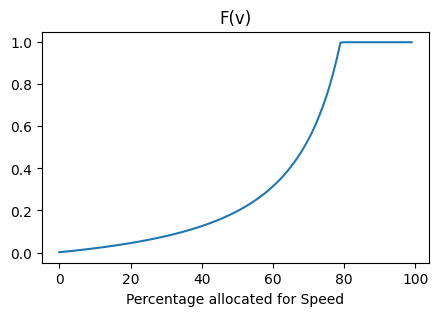

In [10]:
plt.figure(figsize=(5, 3))
plt.plot(f_v)
plt.xlabel("Percentage allocated for Speed")
plt.title("F(v)")
plt.show()

This formula maps the "cost of Speed" against the "reward of Rank". As you bid higher, $F(v)$ must increase to keep the math balanced. You need a progressively higher rank (more people bidding below you) to justify the massive sacrifice you are making to your Research and Scale.

In [11]:
def speed(v):
    return 0.1 + cum_dist(v) * 0.8

In [12]:
def pnl(v):
    b, (r, s) = base(v)
    return b * speed(v) - 50000

In [13]:
results = {}
for v in range(1, 100):
    b, (r, s) = base(v)
    pnl = b * speed(v) - 50000
    results[(r, s, v)] = pnl

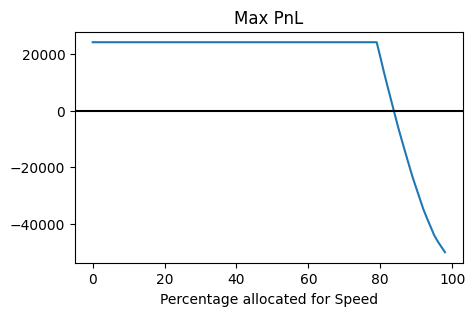

In [14]:
plt.figure(figsize=(5, 3))
plt.plot(results.values())
plt.axhline(0, c='k')
plt.xlabel("Percentage allocated for Speed")
plt.title("Max PnL")
plt.show()

# Naive solution 1 (mistake)

Assuming Scale and Speed peprcentages themselves are multiplied with the research output:
$$\text{Gross PnL} \propto \ln(1+r) \times s \times v \quad s.t. \quad r + s + v = 100.$$ \
In order for $s \times v$ to be maximum, $s = v$. Therefore, the function below must me maximised. \
$$f(r) = \ln(1+r) \times \left( \frac{100 - r}{2} \right)^2$$

In [15]:
def f(r):
    return np.log(1 + r) * (100 - r) ** 2 / 4

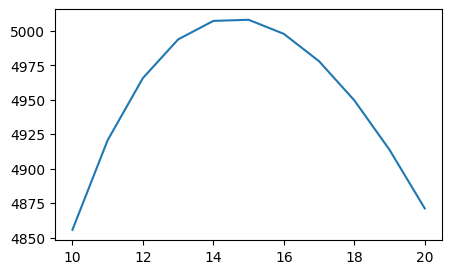

In [16]:
fs = []
for r in range(10, 21):
    fs.append(f(r))

plt.figure(figsize=(5, 3))
plt.plot(range(10, 21), fs)
plt.show()

In [17]:
for r in range(10, 20):
    print(f"{r}: {f(r)}")

10: 4855.737927416701
11: 4920.736393242688
12: 4965.7419560455355
13: 4993.756231964473
14: 5007.184821837986
15: 5007.988379545604
16: 4997.788338915166
17: 4977.942760036669
18: 4949.601923978786
19: 4913.749861696933


In [18]:
print(f"If r = {14}, s = v = {(100 - 14) / 2}")
print(f"If r = {15}, s = v = {(100 - 15) / 2}")

If r = 14, s = v = 43.0
If r = 15, s = v = 42.5


# Naive solution 2

In [19]:
# Assuming speed scales linearly
def speed(v):
    return 0.1 + v / 100 * 0.8
def pnl(r, s, v):
    return research(r) * scale(s) * speed(v) - 50000

In [20]:
results = {}
for r in range(1, 100):
    for s in range(1, 100 - r):
        v = 100 - r - s
        results[(r, s, v)] = pnl(r, s, v)
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
i = 0
for k, v in sorted_results.items():
    print(f"{k}: {v}")
    i += 1
    if i >= 10:
        break

(16, 48, 36): 110065.31395662151
(16, 49, 35): 110030.93566754146
(16, 47, 37): 109962.17908938142
(17, 48, 35): 109927.63989650577
(15, 49, 36): 109903.6021547303
(17, 47, 36): 109892.56804565131
(15, 48, 37): 109869.9594864882
(16, 50, 34): 109859.04422214135
(17, 49, 34): 109822.42434394229
(15, 50, 35): 109802.674150004


# Solution

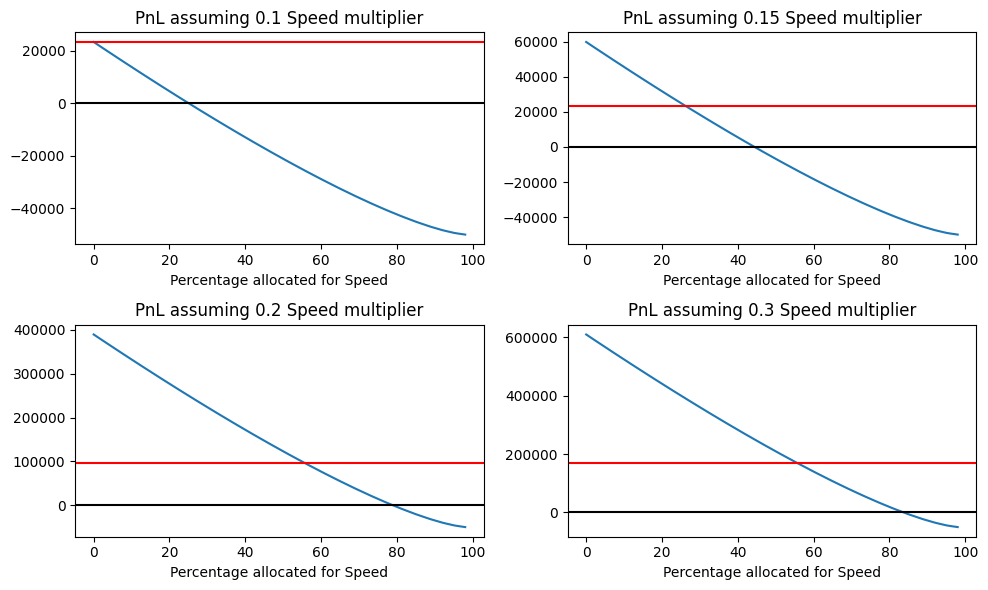

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0, 0].plot(np.array(bs) * 0.1 - 50000)
ax[0, 0].axhline(0, c='k')
ax[0, 0].axhline(bs[0] * 0.1 - 50000, c='r')
ax[0, 0].set_xlabel("Percentage allocated for Speed")
ax[0, 0].set_title("PnL assuming 0.1 Speed multiplier")
ax[0, 1].plot(np.array(bs) * 0.15 - 50000)
ax[0, 1].axhline(0, c='k')
ax[0, 1].axhline(bs[0] * 0.1 - 50000, c='r')
ax[0, 1].set_xlabel("Percentage allocated for Speed")
ax[0, 1].set_title("PnL assuming 0.15 Speed multiplier")
ax[1, 0].plot(np.array(bs) * 0.6 - 50000)
ax[1, 0].axhline(0, c='k')
ax[1, 0].axhline(bs[0] * 0.2 - 50000, c='r')
ax[1, 0].set_xlabel("Percentage allocated for Speed")
ax[1, 0].set_title("PnL assuming 0.2 Speed multiplier")
ax[1, 1].plot(np.array(bs) * 0.9 - 50000)
ax[1, 1].axhline(0, c='k')
ax[1, 1].axhline(bs[0] * 0.3 - 50000, c='r')
ax[1, 1].set_xlabel("Percentage allocated for Speed")
ax[1, 1].set_title("PnL assuming 0.3 Speed multiplier")
plt.tight_layout()
plt.show()

## Cohort simulation 1 (Initial assumtion about cohorts)

In [22]:
def get_expected_speed_distribution(n_participants=10000):
    """
    Generates an expected distribution of the percentage of budget 
    allocated to the 'Speed' pillar (v) by IMC Prosperity participants.
    
    Returns a numpy array of size n_participants containing the simulated bids (0 to 100).
    """
    # Define the behavioral cohorts and their estimated proportions
    proportions = {
        "zen_opt_out": 0.08,      # Bids exactly at 0%
        "naive_split": 0.12,      # Bids around 33.3%
        "level_1_anchor": 0.25,   # Bids around 50% - 51%
        "meme_bidders": 0.05,     # Bids exactly at 69%
        "try_hards": 0.15,        # Bids just under the 80.4% mathematical boundary
        "nash_approximators": 0.35 # The continuous distribution up to 80.4%
    }

    bids = []
    
    # 1. The "Zen" Opt-Out (Exactly 0)
    n_zen = int(n_participants * proportions["zen_opt_out"])
    bids.extend(np.zeros(n_zen))
    
    # 2. The Naive Even Split (~33.3)
    # Using a tight normal distribution because humans aren't perfectly exact
    n_naive = int(n_participants * proportions["naive_split"])
    bids.extend(np.random.normal(loc=33.33, scale=0.5, size=n_naive))
    
    # 3. The Level-1 Anchor (~50 to 51)
    # Bi-modal spike right at 50.0 and 51.0
    n_level1 = int(n_participants * proportions["level_1_anchor"])
    # bids.extend(np.random.normal(loc=50.5, scale=1.0, size=n_level1))
    bids.extend(np.random.normal(loc=51, scale=1.0, size=n_level1))
    
    # 4. The Meme Bidders (~69)
    n_meme = int(n_participants * proportions["meme_bidders"])
    bids.extend(np.random.normal(loc=69.0, scale=0.1, size=n_meme))
    
    # 5. The Try-Hard Boundary (~79.5 to 80.4)
    # Clustered right up against the 80.4 ceiling
    n_tryhards = int(n_participants * proportions["try_hards"])
    bids.extend(np.random.normal(loc=79.8, scale=0.3, size=n_tryhards))
    
    # 6. The Nash Approximators (Continuous right-skewed curve)
    # Modeled using a Beta(4, 2) distribution scaled to the [0, 80.4] range
    n_nash = n_participants - (n_zen + n_naive + n_level1 + n_meme + n_tryhards)
    nash_base = np.random.beta(a=4, b=2, size=n_nash) 
    nash_scaled = nash_base * 80.4
    bids.extend(nash_scaled)
    
    # Convert to array, ensure no values break the 0-100 constraint
    bids_array = np.array(bids)
    bids_array = np.clip(bids_array, 0.0, 100.0)
    
    # Shuffle to simulate random player submission order
    np.random.shuffle(bids_array)
    
    return bids_array

In [23]:
def plot_distribution(bids):
    """
    Plots the probability density histogram of the simulated bids.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot histogram with fine bins to capture the spikes
    count, bins, ignored = plt.hist(bids, bins=200, density=True, alpha=0.7, color='#2ca02c', edgecolor='black', linewidth=0.5)
    
    plt.title('Expected Distribution of Speed Allocation ($v$) Among Prosperity Participants', fontsize=14)
    plt.xlabel('Percentage of Budget Allocated to Speed (%)', fontsize=12)
    plt.ylabel('Density of Participants', fontsize=12)
    plt.xlim(-2, 100)
    
    # Highlight the mathematical maximum boundary
    plt.axvline(x=80.4, color='red', linestyle='--', linewidth=2, label='Rational Max Boundary (80.4%)')
    
    # Annotate the behavioral spikes
    plt.annotate('Zen Opt-Out (0%)', xy=(0, 0.05), xytext=(5, 0.08), arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.annotate('Naive Split (33%)', xy=(33.3, 0.04), xytext=(20, 0.06), arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.annotate('Level-1 Anchor (50-51%)', xy=(50.5, 0.05), xytext=(35, 0.08), arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.annotate('Meme (69%)', xy=(69, 0.06), xytext=(55, 0.09), arrowprops=dict(facecolor='black', arrowstyle='->'))
    plt.annotate('Try-Hards (~80%)', xy=(80, 0.08), xytext=(82, 0.10), arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [24]:
def calculate_rank_factor(data):
    """
    Calculates the Rank Scaling Factor for x in 0 to 100 based on 
    Standard Competition Ranking (1224 ranking).
    Returns a dictionary mapping x to a factor between 0.0 and 1.0.
    """
    if not data:
        return {x: 0.0 for x in range(101)}
        
    counts = Counter(data)
    
    # Calculate how many items are STRICTLY GREATER than x
    # We iterate backwards from 100 down to 0 to keep a running total
    strictly_greater = {}
    cumulative_greater = 0
    
    for x in range(100, -1, -1):
        strictly_greater[x] = cumulative_greater
        cumulative_greater += counts.get(x, 0)
        
    # Rank is simply 1 + (number of people who bid higher than you)
    # The maximum rank in the game is defined by the lowest bid actually submitted
    min_bid_in_data = min(data)
    max_rank = 1 + strictly_greater[min_bid_in_data]
    
    factors = {}
    for x in range(101):
        # If the bid is lower than anything in the dataset, it assumes the max rank
        if x < min_bid_in_data:
            rank_x = max_rank
        else:
            rank_x = 1 + strictly_greater[x]
            
        # Edge case: If literally everyone bid the exact same number
        if max_rank == 1:
            factors[x] = 1.0 
        else:
            # Scale from 1.0 (Rank 1) down to 0.0 (Max Rank)
            factors[x] = 1.0 - ((rank_x - 1) / (max_rank - 1))
            
    return factors

In [25]:
def cum_dist_real(v, simulated_bids):
    rfs = calculate_rank_factor(list(simulated_bids))
    return rfs[v]

In [26]:
def speed_real(v, simulated_bids):
    return 0.1 + cum_dist_real(v, simulated_bids) * 0.8

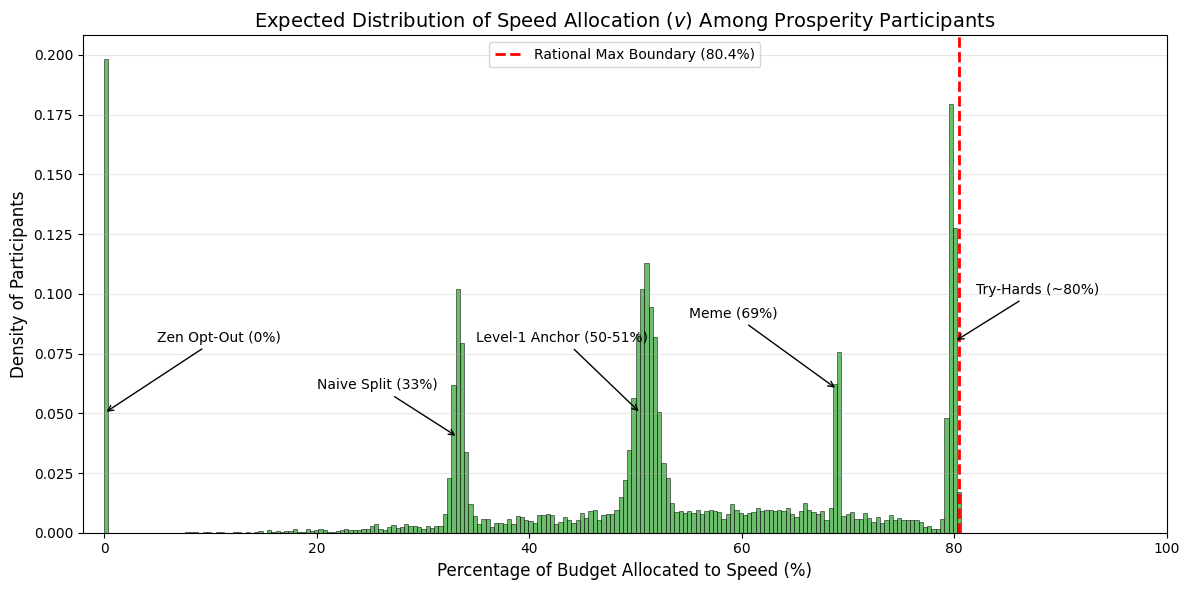

In [27]:
simulated_bids = get_expected_speed_distribution(10000)
plot_distribution(simulated_bids)

In [28]:
simulated_bids = np.int_(simulated_bids)

In [29]:
f_v_real, ss = [], []
for v in range(100):
    f_v_real.append(cum_dist_real(v, simulated_bids))
    ss.append(speed_real(v, simulated_bids))

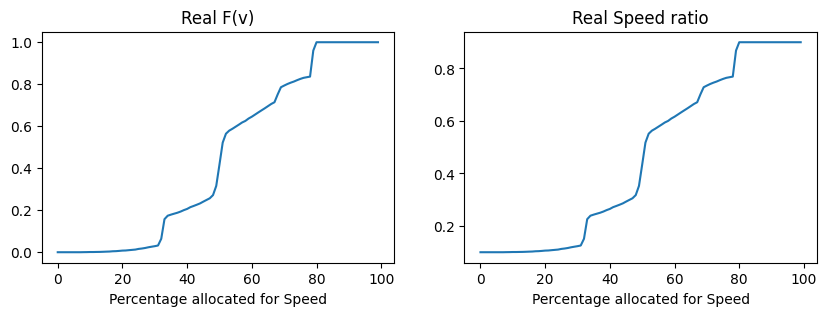

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(f_v_real)
ax[0].set_xlabel("Percentage allocated for Speed")
ax[0].set_title("Real F(v)")
ax[1].plot(ss)
ax[1].set_xlabel("Percentage allocated for Speed")
ax[1].set_title("Real Speed ratio")
plt.show()

In [31]:
results = {}
for v in range(0, 100):
    b, (r, s) = base(v)
    pnl = b * speed_real(v, simulated_bids) - 50000
    results[(r, s, v)] = pnl

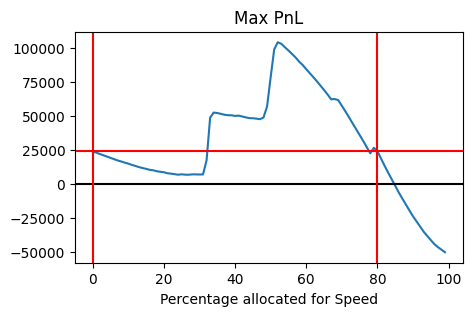

In [32]:
plt.figure(figsize=(5, 3))
plt.plot(results.values())
plt.axhline(0, c='k')
plt.axhline(list(results.values())[0], c='r')
plt.axvline(80, c='r')
plt.axvline(0, c='r')
plt.xlabel("Percentage allocated for Speed")
plt.title("Max PnL")
plt.show()

In [33]:
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
i = 0
for k, v in sorted_results.items():
    print(f"Research: {k[0]}, Scale: {k[1]}, Speed: {k[2]}  ->  Expected PnL: {v}")
    i += 1
    if i >= 10:
        break

Research: 13, Scale: 35, Speed: 52  ->  Expected PnL: 104521.97687332178
Research: 12, Scale: 35, Speed: 53  ->  Expected PnL: 103356.01971389662
Research: 12, Scale: 34, Speed: 54  ->  Expected PnL: 100860.75367355056
Research: 13, Scale: 36, Speed: 51  ->  Expected PnL: 99188.15975027182
Research: 12, Scale: 33, Speed: 55  ->  Expected PnL: 98455.47417967027
Research: 12, Scale: 32, Speed: 56  ->  Expected PnL: 95927.05520115254
Research: 11, Scale: 32, Speed: 57  ->  Expected PnL: 93344.878196364
Research: 11, Scale: 31, Speed: 58  ->  Expected PnL: 90247.09553633686
Research: 11, Scale: 30, Speed: 59  ->  Expected PnL: 87787.74713590907
Research: 11, Scale: 29, Speed: 60  ->  Expected PnL: 84715.52806533198


## Cohort simulation 2 (Incorporated information from Discord chat)

In [61]:
def get_expected_speed_distribution(n_participants=10000):
    """
    Generates an expected distribution of the percentage of budget 
    allocated to the 'Speed' pillar (v) by IMC Prosperity participants,
    heavily informed by Level-k behavioral clustering and Discord sentiment.
    
    Returns a numpy array of size n_participants containing the simulated bids (0 to 100).
    """
    # Updated behavioral cohorts and their estimated proportions based on actual game theory
    proportions = {
        "zen_opt_out": 0.03,      # Believes in the 0.1 floor (shrunk due to "0 breaks formula" rumor)
        "paranoid_low": 0.08,     # Bids 1% to 5% to "just beat the zeros"
        "mid_20s_war": 0.12,      # The iterative Level-k bidding war between 25% and 31%
        "naive_split": 0.10,      # Exhausted players bidding exactly ~33.3%
        "linear_fallacy": 0.15,   # The massive cluster bidding ~36% due to the linear-scaling math error
        "level_1_anchor": 0.20,   # The standard "smart" anchor around 50% - 51%
        "meme_bidders": 0.05,     # Trolls bidding exactly 69%
        "try_hards": 0.10,        # Bids just under the 80.4% true mathematical boundary
        "kamikaze_trolls": 0.02   # Bids exactly 100% just to steal the 0.9 multiplier
        # The remainder (~15%) will be the continuous Nash Approximators
    }
    
    bids = []
    
    # 1. The "Zen" Opt-Out (Exactly 0)
    n_zen = int(n_participants * proportions["zen_opt_out"])
    bids.extend(np.zeros(n_zen))
    
    # 2. The Paranoid Low (Uniform spread between 1.0 and 5.0)
    n_paranoid = int(n_participants * proportions["paranoid_low"])
    bids.extend(np.random.uniform(low=1.0, high=5.0, size=n_paranoid))
    
    # 3. The Mid-20s Game Theory War (~28.0)
    n_mid20s = int(n_participants * proportions["mid_20s_war"])
    bids.extend(np.random.normal(loc=28.0, scale=2.0, size=n_mid20s))
    
    # 4. The Naive Even Split (~33.3)
    n_naive = int(n_participants * proportions["naive_split"])
    bids.extend(np.random.normal(loc=33.33, scale=0.5, size=n_naive))
    
    # 5. The Linear Fallacy Cluster (~36.0) - Your reverse-engineered discovery!
    n_linear = int(n_participants * proportions["linear_fallacy"])
    bids.extend(np.random.normal(loc=36.0, scale=1.0, size=n_linear))
    
    # 6. The Level-1 Anchor (~50 to 51)
    n_level1 = int(n_participants * proportions["level_1_anchor"])
    bids.extend(np.random.normal(loc=50.5, scale=1.0, size=n_level1))
    
    # 7. The Meme Bidders (~69)
    n_meme = int(n_participants * proportions["meme_bidders"])
    bids.extend(np.random.normal(loc=69.0, scale=0.1, size=n_meme))
    
    # 8. The Try-Hard Boundary (~79.5 to 80.4)
    n_tryhards = int(n_participants * proportions["try_hards"])
    bids.extend(np.random.normal(loc=79.8, scale=0.3, size=n_tryhards))
    
    # 9. The 100% Kamikaze Trolls (Exactly 100)
    n_kamikaze = int(n_participants * proportions["kamikaze_trolls"])
    bids.extend(np.full(n_kamikaze, 100.0))
    
    # 10. The Nash Approximators (Continuous right-skewed curve)
    # Calculate the exact remaining number of players to ensure we hit n_participants
    n_nash = n_participants - (n_zen + n_paranoid + n_mid20s + n_naive + n_linear + n_level1 + n_meme + n_tryhards + n_kamikaze)
    nash_base = np.random.beta(a=4, b=2, size=n_nash) 
    nash_scaled = nash_base * 80.4
    bids.extend(nash_scaled)
    
    # Convert to array, ensure no values break the 0-100 constraint
    bids_array = np.array(bids)
    bids_array = np.clip(bids_array, 0.0, 100.0)
    
    # Shuffle to simulate random player submission order
    np.random.shuffle(bids_array)
    
    return bids_array

In [62]:
def plot_distribution(bids):
    """
    Plots the probability density histogram of the simulated bids.
    """
    plt.figure(figsize=(14, 7)) # Slightly wider to accommodate more labels
    
    # Plot histogram with fine bins to capture the spikes
    count, bins, ignored = plt.hist(bids, bins=200, density=True, alpha=0.7, color='#2ca02c', edgecolor='black', linewidth=0.5)
    
    plt.title('Expected Distribution of Speed Allocation ($v$) Among Prosperity Participants', fontsize=14)
    plt.xlabel('Percentage of Budget Allocated to Speed (%)', fontsize=12)
    plt.ylabel('Density of Participants', fontsize=12)
    
    # Extended upper bound to fit the 100% Kamikaze label
    plt.xlim(-2, 105) 
    
    # Highlight the mathematical maximum boundary
    plt.axvline(x=80.4, color='red', linestyle='--', linewidth=2, label='Rational Max Boundary (80.4%)')
    
    # Annotate the behavioral spikes
    # Staggered the y-coordinates for text (xytext) to prevent overlapping in the dense 30s
    plt.annotate('Zen Opt-Out (0%)', xy=(0, 0.03), xytext=(2, 0.09), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Paranoid Low (1-5%)', xy=(3, 0.015), xytext=(8, 0.06), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Mid-20s War (~28%)', xy=(28, 0.02), xytext=(15, 0.07), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Naive Split (33%)', xy=(33.3, 0.04), xytext=(22, 0.09), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Linear Fallacy (~36%)', xy=(36, 0.05), xytext=(38, 0.11), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Level-1 Anchor (50%)', xy=(50.5, 0.03), xytext=(45, 0.12), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Meme (69%)', xy=(69, 0.05), xytext=(55, 0.11), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Try-Hards (~80%)', xy=(80, 0.04), xytext=(70, 0.07), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Kamikaze (100%)', xy=(100, 0.02), xytext=(88, 0.05), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

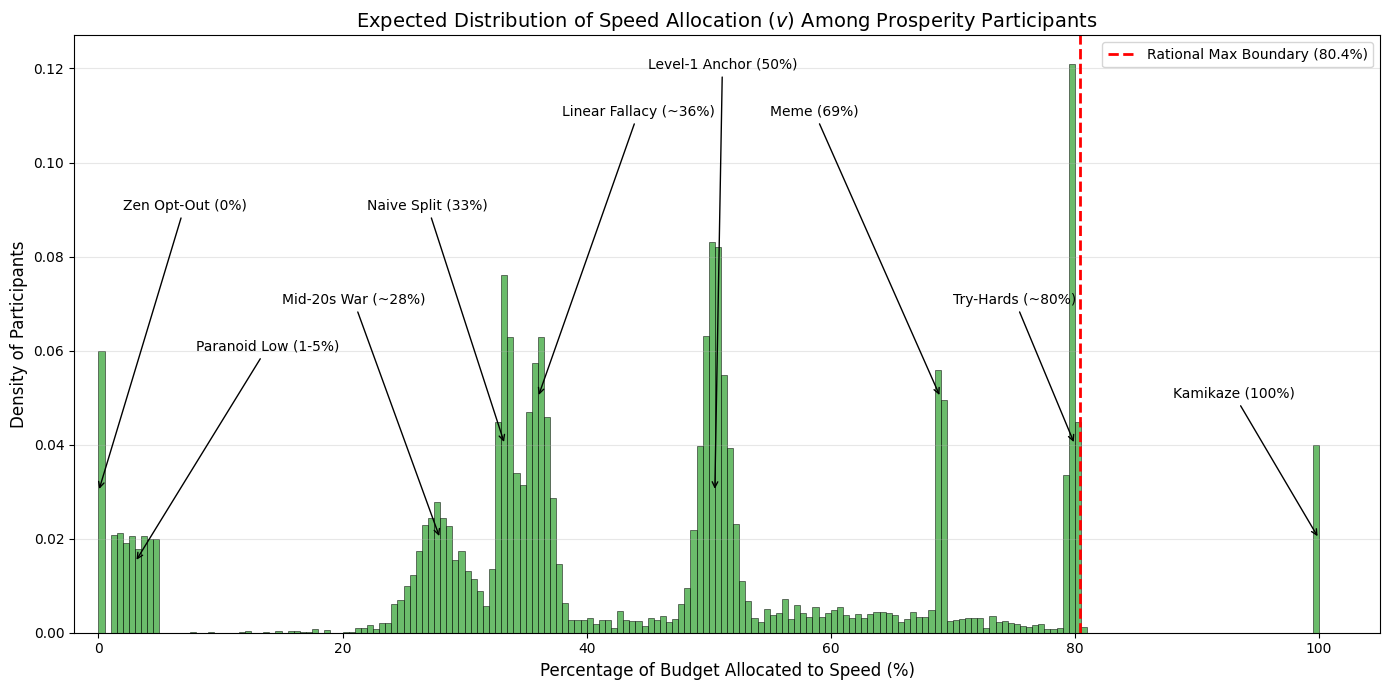

In [63]:
simulated_bids = get_expected_speed_distribution(10000)
plot_distribution(simulated_bids)

In [37]:
simulated_bids = np.int_(simulated_bids)

In [38]:
f_v_real, ss = [], []
for v in range(100):
    f_v_real.append(cum_dist_real(v, simulated_bids))
    ss.append(speed_real(v, simulated_bids))

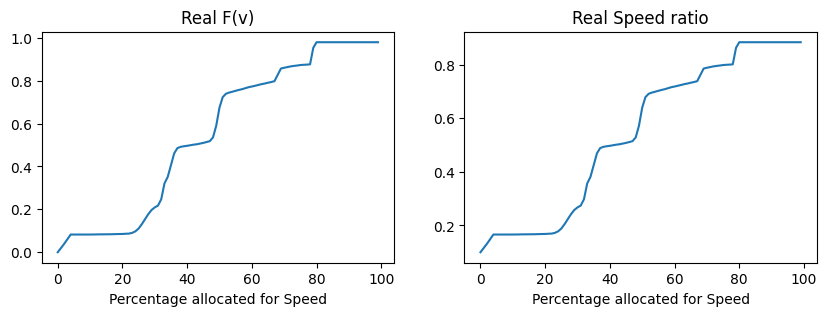

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(f_v_real)
ax[0].set_xlabel("Percentage allocated for Speed")
ax[0].set_title("Real F(v)")
ax[1].plot(ss)
ax[1].set_xlabel("Percentage allocated for Speed")
ax[1].set_title("Real Speed ratio")
plt.show()

In [40]:
results = {}
for v in range(0, 100):
    b, (r, s) = base(v)
    pnl = b * speed_real(v, simulated_bids) - 50000
    results[(r, s, v)] = pnl

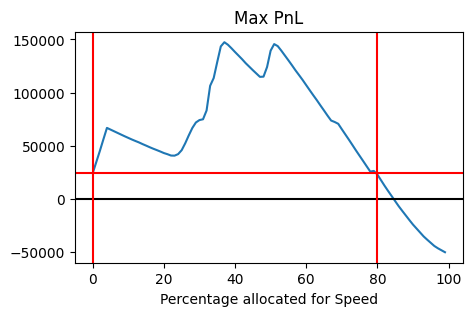

In [41]:
plt.figure(figsize=(5, 3))
plt.plot(results.values())
plt.axhline(0, c='k')
plt.axhline(list(results.values())[0], c='r')
plt.axvline(80, c='r')
plt.axvline(0, c='r')
plt.xlabel("Percentage allocated for Speed")
plt.title("Max PnL")
plt.show()

In [42]:
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
i = 0
for k, v in sorted_results.items():
    print(f"Research: {k[0]}, Scale: {k[1]}, Speed: {k[2]}  ->  Expected PnL: {v}")
    i += 1
    if i >= 10:
        break

Research: 16, Scale: 47, Speed: 37  ->  Expected PnL: 147341.65736456332
Research: 13, Scale: 36, Speed: 51  ->  Expected PnL: 145584.86333750165
Research: 16, Scale: 46, Speed: 38  ->  Expected PnL: 144968.84658733857
Research: 13, Scale: 35, Speed: 52  ->  Expected PnL: 143687.61898757858
Research: 16, Scale: 48, Speed: 36  ->  Expected PnL: 143408.7102107376
Research: 15, Scale: 46, Speed: 39  ->  Expected PnL: 141658.46582733348
Research: 12, Scale: 35, Speed: 53  ->  Expected PnL: 139439.01358460935
Research: 13, Scale: 37, Speed: 50  ->  Expected PnL: 139413.78475161127
Research: 15, Scale: 45, Speed: 40  ->  Expected PnL: 138116.27437623419
Research: 12, Scale: 34, Speed: 54  ->  Expected PnL: 134877.384127139


# Sensitivity analysis

In [43]:
# --- 1. CORE MATH FUNCTIONS ---

def research(r):
    return 200_000 * np.log(1 + r) / np.log(1 + 100)

def scale(s):
    return (s / 100) * 7

def base(v):
    """Calculates the absolute best Base PnL for a given integer v."""
    results = {}
    for r in range(0, 101 - int(v)):  
        s = 100 - int(v) - r  
        results[(r, s)] = research(r) * scale(s)
        
    if not results:
        return 0, (0, 0)
        
    b = max(results.values())
    optimal_pcts = [k for k, val in results.items() if val == b][0]
    return b, optimal_pcts

def calculate_rank_factor(data):
    """Calculates Standard Competition Rank Factor (0.0 to 1.0)."""
    if not data:
        return {x: 0.0 for x in range(101)}
        
    counts = Counter(data)
    strictly_greater = {}
    cumulative_greater = 0
    
    for x in range(100, -1, -1):
        strictly_greater[x] = cumulative_greater
        cumulative_greater += counts.get(x, 0)
        
    min_bid_in_data = min(data)
    max_rank = 1 + strictly_greater[min_bid_in_data]
    
    factors = {}
    for x in range(101):
        if x < min_bid_in_data:
            rank_x = max_rank
        else:
            rank_x = 1 + strictly_greater[x]
            
        if max_rank == 1:
            factors[x] = 1.0 
        else:
            factors[x] = 1.0 - ((rank_x - 1) / (max_rank - 1))
            
    return factors

# --- 2. POPULATION GENERATOR ---

def generate_population(proportions, n_participants=10000):
    """Generates the integer bids based on specific cohort proportions."""
    bids = []
    
    n_zen = int(n_participants * proportions.get("zen_opt_out", 0))
    bids.extend(np.zeros(n_zen))
    
    n_paranoid = int(n_participants * proportions.get("paranoid_low", 0))
    bids.extend(np.random.uniform(1.0, 5.0, size=n_paranoid))
    
    n_mid20s = int(n_participants * proportions.get("mid_20s_war", 0))
    bids.extend(np.random.normal(loc=28.0, scale=2.0, size=n_mid20s))
    
    n_naive = int(n_participants * proportions.get("naive_split", 0))
    bids.extend(np.random.normal(loc=33.33, scale=0.5, size=n_naive))
    
    n_linear = int(n_participants * proportions.get("linear_fallacy", 0))
    bids.extend(np.random.normal(loc=36.0, scale=1.0, size=n_linear))
    
    n_level1 = int(n_participants * proportions.get("level_1_anchor", 0))
    bids.extend(np.random.normal(loc=50.5, scale=1.0, size=n_level1))
    
    n_meme = int(n_participants * proportions.get("meme_bidders", 0))
    bids.extend(np.random.normal(loc=69.0, scale=0.1, size=n_meme))
    
    n_tryhards = int(n_participants * proportions.get("try_hards", 0))
    bids.extend(np.random.normal(loc=79.8, scale=0.3, size=n_tryhards))
    
    n_kamikaze = int(n_participants * proportions.get("kamikaze_trolls", 0))
    bids.extend(np.full(n_kamikaze, 100.0))
    
    # Fill the rest with Nash Approximators (Continuous)
    n_nash = n_participants - len(bids)
    if n_nash > 0:
        nash_base = np.random.beta(a=4, b=2, size=n_nash) 
        nash_scaled = nash_base * 80.4
        bids.extend(nash_scaled)
    
    bids_array = np.clip(np.array(bids), 0.0, 100.0)
    
    # CRITICAL: We enforce integer bids here for the simulation to match reality
    bids_array = np.round(bids_array).astype(int) 
    
    return bids_array

# --- 3. SCENARIO DEFINITIONS ---

scenarios = {
    "Baseline (Our best Discord guess)": {
        "zen_opt_out": 0.03, "paranoid_low": 0.08, "mid_20s_war": 0.12, "naive_split": 0.10, 
        "linear_fallacy": 0.15, "level_1_anchor": 0.20, "meme_bidders": 0.05, 
        "try_hards": 0.10, "kamikaze_trolls": 0.02
    },
    "Heavy Linear Fallacy (Everyone makes the math mistake)": {
        "zen_opt_out": 0.02, "paranoid_low": 0.05, "mid_20s_war": 0.10, "naive_split": 0.05, 
        "linear_fallacy": 0.35, "level_1_anchor": 0.15, "meme_bidders": 0.03, 
        "try_hards": 0.05, "kamikaze_trolls": 0.02
    },
    "High Anchor (The 50% strategy dominates)": {
        "zen_opt_out": 0.02, "paranoid_low": 0.05, "mid_20s_war": 0.05, "naive_split": 0.05, 
        "linear_fallacy": 0.08, "level_1_anchor": 0.40, "meme_bidders": 0.05, 
        "try_hards": 0.10, "kamikaze_trolls": 0.02
    },
    "Troll Heavy (Chaos and Memes)": {
        "zen_opt_out": 0.05, "paranoid_low": 0.10, "mid_20s_war": 0.10, "naive_split": 0.10, 
        "linear_fallacy": 0.10, "level_1_anchor": 0.15, "meme_bidders": 0.15, 
        "try_hards": 0.05, "kamikaze_trolls": 0.08
    },
    "Zero Renaissance (People realize 0 is safe)": {
        "zen_opt_out": 0.20, "paranoid_low": 0.05, "mid_20s_war": 0.10, "naive_split": 0.10, 
        "linear_fallacy": 0.10, "level_1_anchor": 0.15, "meme_bidders": 0.05, 
        "try_hards": 0.10, "kamikaze_trolls": 0.02
    }
}

# --- 4. EXECUTION AND EVALUATION ---

print("Simulating behavioral scenarios...\n")

# Store PnLs for every v across all iterations
# Structure: v_performance[v] = [pnl_run1, pnl_run2, ...]
v_performance = {v: [] for v in range(101)}

# We run 3 iterations per scenario to smooth out the random noise
ITERATIONS_PER_SCENARIO = 3 

for scenario_name, proportions in scenarios.items():
    for _ in range(ITERATIONS_PER_SCENARIO):
        population = generate_population(proportions, n_participants=10000)
        rank_factors = calculate_rank_factor(list(population))
        
        for v in range(100):
            b, _ = base(v)
            multiplier = 0.1 + (rank_factors.get(v, 0) * 0.8)
            pnl = (b * multiplier) - 50_000
            v_performance[v].append(pnl)

# Calculate summary statistics for each v
v_stats = {}
for v, pnls in v_performance.items():
    if v < 100: # Exclude v=100 since Base PnL is 0 and it always loses money
        v_stats[v] = {
            "mean": np.mean(pnls),
            "min": np.min(pnls),
            "max": np.max(pnls)
        }

# Sort by highest expected (mean) PnL
sorted_v = sorted(v_stats.items(), key=lambda item: item[1]["mean"], reverse=True)

print("=== TOP 5 MOST ROBUST ALLOCATIONS FOR SPEED ===")
print("Ranked by Expected PnL across all unpredictable scenarios:\n")

for i in range(5):
    v = sorted_v[i][0]
    stats = sorted_v[i][1]
    _, (r, s) = base(v)
    
    print(f"Option {i+1}: Speed = {v}% (Research: {r}%, Scale: {s}%)")
    print(f"   Expected PnL: {stats['mean']:,.0f} XIRECs")
    print(f"   Worst Case:   {stats['min']:,.0f} XIRECs")
    print(f"   Best Case:    {stats['max']:,.0f} XIRECs\n")

print("=== THE ZEN BASELINE (For Comparison) ===")
v_zen = 0
zen_stats = v_stats[0]
_, (r_zen, s_zen) = base(0)
print(f"Option: Speed = 0% (Research: {r_zen}%, Scale: {s_zen}%)")
print(f"   Expected PnL: {zen_stats['mean']:,.0f} XIRECs")
print(f"   Worst Case:   {zen_stats['min']:,.0f} XIRECs\n")

Simulating behavioral scenarios...

=== TOP 5 MOST ROBUST ALLOCATIONS FOR SPEED ===
Ranked by Expected PnL across all unpredictable scenarios:

Option 1: Speed = 52% (Research: 13%, Scale: 35%)
   Expected PnL: 137,492 XIRECs
   Worst Case:   118,790 XIRECs
   Best Case:    156,499 XIRECs

Option 2: Speed = 51% (Research: 13%, Scale: 36%)
   Expected PnL: 134,897 XIRECs
   Worst Case:   117,982 XIRECs
   Best Case:    155,999 XIRECs

Option 3: Speed = 53% (Research: 12%, Scale: 35%)
   Expected PnL: 134,128 XIRECs
   Worst Case:   115,312 XIRECs
   Best Case:    152,478 XIRECs

Option 4: Speed = 37% (Research: 16%, Scale: 47%)
   Expected PnL: 131,726 XIRECs
   Worst Case:   72,799 XIRECs
   Best Case:    174,725 XIRECs

Option 5: Speed = 38% (Research: 16%, Scale: 46%)
   Expected PnL: 131,602 XIRECs
   Worst Case:   72,768 XIRECs
   Best Case:    177,464 XIRECs

=== THE ZEN BASELINE (For Comparison) ===
Option: Speed = 0% (Research: 23%, Scale: 77%)
   Expected PnL: 24,233 XIRECs
   

# Decision

The choice of 52 for Speed allocation seems robust considering varying cohort simulations.

In [44]:
print("Final choice:")
print(f"Research: {13}, Scale: {35}, Speed: {52}")

Final choice:
Research: 13, Scale: 35, Speed: 52


# Final results

In [45]:
speed_counts = [453, 125, 84, 52, 27, 129, 27, 31, 30, 12, 249, 53, 29, 17, 5, 137, 35, 22, 23, 13, 281,
                78, 44, 33, 22, 172, 63, 54, 22, 14, 242, 57, 42, 68, 99, 155, 184, 118, 75, 37, 227,
                139, 119, 89, 40, 100, 69, 42, 20, 14, 86, 62, 56, 40, 22, 33, 21, 17, 17, 4, 30,
                15, 3, 7, 8, 9, 5, 4, 3, 3, 8, 9, 2, 0, 1, 1, 1, 2, 1, 1, 4,
                2, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2]
speed_values = range(0, 101)
speed_bids = []
for v, ct in zip(speed_values, speed_counts):
    speed_bids.extend([v] * ct)

In [46]:
print(f"Number of bidders: {len(speed_bids)}")

Number of bidders: 4754


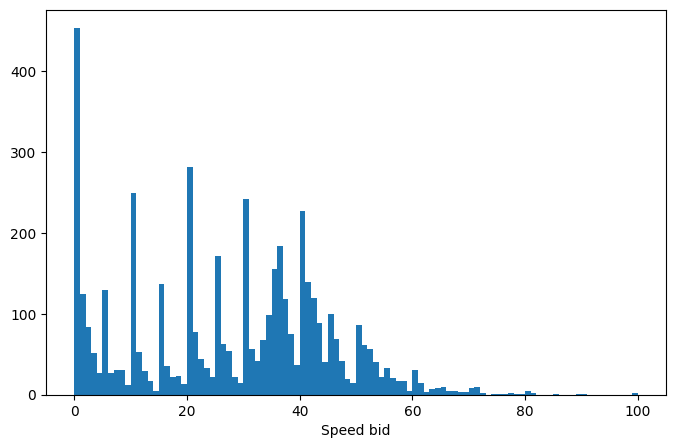

In [47]:
plt.figure(figsize=(8, 5))
plt.hist(speed_bids, bins=100)
plt.xlabel("Speed bid")
plt.show()

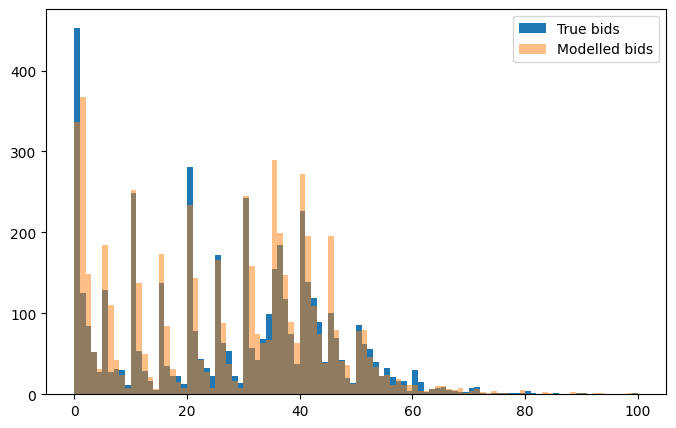

In [48]:
dist_list = [
    np.random.exponential(scale=1, size=900),  # Zero and one-uppers
    50 + np.random.exponential(scale=2, size=250),  # Center and one-uppers
    np.random.uniform(0, 10, 100),  # Random low (1-digit) number
    np.random.normal(50, 15, 300),  # Central tendency
    np.random.normal(36, 2, 600),  # Naive 2 approach
    np.random.normal(42, 1.5, 200),  # Naive 1 approach
    np.random.uniform(0, 100, 100)  # Random
]

# Round numbers (Base-5 and Base-10 Heuristic)
for n in range(10, 41, 10):
    dist_list.append(n + np.random.exponential(scale=1, size=350))
    dist_list.append(np.array(100 * [n]))
for n in range(5, 46, 10):
    dist_list.append(n + np.random.exponential(scale=1, size=200))
    dist_list.append(np.array(100 * [n]))

modelled_bids = []
for dist in dist_list:
    modelled_bids.extend(list(dist))
modelled_bids.append(100)

modelled_bids = [round(b) for b in modelled_bids]
modelled_bids = np.clip(modelled_bids, 0, 100)

plt.figure(figsize=(8, 5))
plt.hist(speed_bids, bins=100, label='True bids')
plt.hist(modelled_bids, bins=100, alpha=0.5, label='Modelled bids')
plt.legend()
plt.show()

In [49]:
f_v_final, ss_final = [], []
for v in range(100):
    f_v_final.append(cum_dist_real(v, speed_bids))
    ss_final.append(speed_real(v, speed_bids))

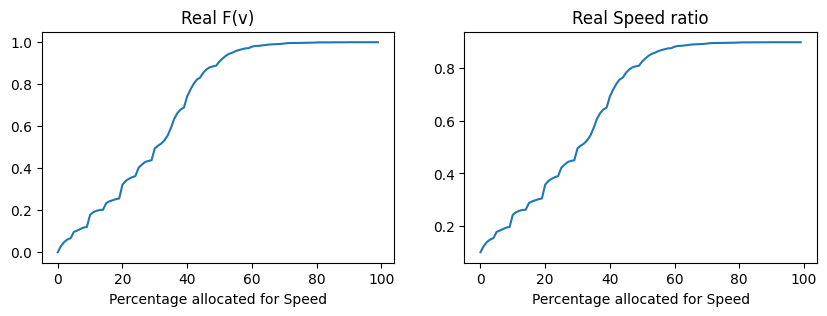

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(f_v_final)
ax[0].set_xlabel("Percentage allocated for Speed")
ax[0].set_title("Real F(v)")
ax[1].plot(ss_final)
ax[1].set_xlabel("Percentage allocated for Speed")
ax[1].set_title("Real Speed ratio")
plt.show()

In [51]:
results = {}
for v in range(0, 100):
    b, (r, s) = base(v)
    pnl = b * speed_real(v, speed_bids) - 50000
    results[(r, s, v)] = pnl

In [52]:
sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
i = 0
for k, v in sorted_results.items():
    print(f"Research: {k[0]}, Scale: {k[1]}, Speed: {k[2]}  ->  Expected PnL: {v}")
    i += 1
    if i >= 10:
        break

Research: 15, Scale: 43, Speed: 42  ->  Expected PnL: 217909.9585739068
Research: 15, Scale: 42, Speed: 43  ->  Expected PnL: 217527.26442283846
Research: 15, Scale: 44, Speed: 41  ->  Expected PnL: 215949.16437218862
Research: 14, Scale: 42, Speed: 44  ->  Expected PnL: 213866.97180166753
Research: 14, Scale: 41, Speed: 45  ->  Expected PnL: 213849.20884705312
Research: 15, Scale: 45, Speed: 40  ->  Expected PnL: 212208.06993984885
Research: 14, Scale: 40, Speed: 46  ->  Expected PnL: 211631.13151439387
Research: 14, Scale: 39, Speed: 47  ->  Expected PnL: 207593.21083156002
Research: 16, Scale: 46, Speed: 38  ->  Expected PnL: 204482.06769535868
Research: 16, Scale: 47, Speed: 37  ->  Expected PnL: 204379.1566346971


In [53]:
k, v = [(k, v) for k, v in results.items() if k[2] == 43][0]
print(f"Optimal choice: Research: {k[0]}, Scale: {k[1]}, Speed: {k[2]}  ->  Expected PnL: {v} - True PnL: 217,869")

Optimal choice: Research: 15, Scale: 42, Speed: 43  ->  Expected PnL: 217527.26442283846 - True PnL: 217,869


In [54]:
k, v = [(k, v) for k, v in results.items() if k[2] == 52][0]
print(f"My choice: Research: {k[0]}, Scale: {k[1]}, Speed: {k[2]}  ->  Expected PnL: {v} - True PnL: 187,694")

My choice: Research: 13, Scale: 35, Speed: 52  ->  Expected PnL: 187687.73182699934 - True PnL: 187,694


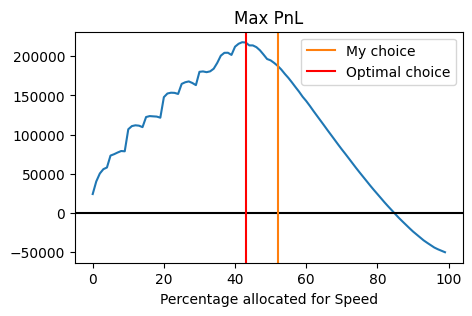

In [55]:
plt.figure(figsize=(5, 3))
plt.plot(results.values())
plt.axhline(0, c='k')
plt.axvline(52, c='tab:orange', label='My choice')
plt.axvline(43, c='r', label='Optimal choice')
plt.xlabel("Percentage allocated for Speed")
plt.title("Max PnL")
plt.legend()
plt.show()

# Updated cohort simulation

In [56]:
def get_expected_speed_distribution(n_participants=10000):
    """
    Generates an expected distribution of the percentage of budget 
    allocated to the 'Speed' pillar (v) by IMC Prosperity participants.
    
    Updated with ground-truth cohort ratios, base-5 heuristics, and compressed 
    upper boundaries based on actual competition data.
    """
    # Updated behavioral cohorts based on empirical data analysis
    proportions = {
        "zen_opt_out": 0.095,      # Back to ~9.5%. The "formula breaks" rumor was largely ignored.
        "paranoid_low": 0.060,     # Bids 1% to 4% (288 actual bids in this range)
        "base_anchors": 0.250,     # NEW: Massive human clustering exactly at 5, 10, 15, 20, 25, 30
        "linear_fallacy": 0.135,   # The massive cluster around ~36% due to the math error
        "forty_battleground": 0.105, # NEW: The intense Level-k bidding war between 40, 41, and 42
        "level_1_anchor": 0.045,   # The 50% anchor was actually much smaller than expected
        "meme_bidders": 0.001,     # Shrunk to ~0.1% (Only 3 real bids at 69)
        "try_hards": 0.005,        # Shrunk to 0.5% (Barely anyone tried to hit the 80.4 boundary)
        "kamikaze_trolls": 0.001   # Shrunk to ~0.1% (Only 2 real bids at 100)
        # The remainder (~30.3%) will be the continuous base "noise", compressed < 55
    }
    
    bids = []
    
    # 1. The "Zen" Opt-Out (Exactly 0)
    n_zen = int(n_participants * proportions["zen_opt_out"])
    bids.extend(np.zeros(n_zen))
    
    # 2. The Paranoid Low (Uniform spread between 1.0 and 4.9)
    n_paranoid = int(n_participants * proportions["paranoid_low"])
    bids.extend(np.random.uniform(low=1.0, high=4.9, size=n_paranoid))
    
    # 3. The Base-5/10 Anchors (Spikes at clean numbers)
    n_base_anchors = int(n_participants * proportions["base_anchors"])
    # We use a slight normal distribution around these anchors so it isn't completely rigid
    anchor_choices = np.random.choice([5, 10, 15, 20, 25, 30], size=n_base_anchors)
    bids.extend(np.random.normal(loc=anchor_choices, scale=0.2))
    
    # 4. The Linear Fallacy Cluster (~36.0)
    n_linear = int(n_participants * proportions["linear_fallacy"])
    bids.extend(np.random.normal(loc=36.0, scale=1.2, size=n_linear))
    
    # 5. The 40 Battleground (Clustered heavily around 40-42)
    n_forty = int(n_participants * proportions["forty_battleground"])
    # Right-skewed slightly because people anchor to 40, then one-up to 41 and 42
    bids.extend(np.random.normal(loc=41.0, scale=1.0, size=n_forty))
    
    # 6. The Level-1 Anchor (~50)
    n_level1 = int(n_participants * proportions["level_1_anchor"])
    bids.extend(np.random.normal(loc=50.5, scale=1.0, size=n_level1))
    
    # 7. The Meme Bidders (~69)
    n_meme = int(n_participants * proportions["meme_bidders"])
    bids.extend(np.random.normal(loc=69.0, scale=0.1, size=n_meme))
    
    # 8. The Try-Hard Boundary (~79.5 to 80.4)
    n_tryhards = int(n_participants * proportions["try_hards"])
    bids.extend(np.random.normal(loc=79.8, scale=0.3, size=n_tryhards))
    
    # 9. The 100% Kamikaze Trolls (Exactly 100)
    n_kamikaze = int(n_participants * proportions["kamikaze_trolls"])
    bids.extend(np.full(n_kamikaze, 100.0))
    
    # 10. The Continuous Base (Compressed to < 55)
    # The actual data showed the field completely dies off after 55
    n_nash = n_participants - len(bids)
    if n_nash > 0:
        # Using Beta(2, 5) to create a left-leaning distribution that tapers off 
        nash_base = np.random.beta(a=2, b=5, size=n_nash) 
        nash_scaled = nash_base * 55.0  # Compressed from 80.4 down to 55 max
        bids.extend(nash_scaled)
    
    # Convert to array, clip strictly to 0-100, and ensure no invalid values
    bids_array = np.clip(np.array(bids), 0.0, 100.0)
    
    # Shuffle to simulate random player submission order
    np.random.shuffle(bids_array)
    
    return bids_array

In [57]:
def plot_distribution(bids):
    """
    Plots the probability density histogram of the simulated bids.
    """
    plt.figure(figsize=(14, 7)) # Slightly wider to accommodate more labels
    
    # Plot histogram with fine bins to capture the spikes
    count, bins, ignored = plt.hist(bids, bins=200, density=True, alpha=0.7, color='#2ca02c', edgecolor='black', linewidth=0.5)
    
    plt.title('Expected Distribution of Speed Allocation ($v$) Among Prosperity Participants', fontsize=14)
    plt.xlabel('Percentage of Budget Allocated to Speed (%)', fontsize=12)
    plt.ylabel('Density of Participants', fontsize=12)
    
    # Extended upper bound to fit the 100% Kamikaze label
    plt.xlim(-2, 105) 
    
    # Highlight the mathematical maximum boundary
    plt.axvline(x=80.4, color='red', linestyle='--', linewidth=2, label='Rational Max Boundary (80.4%)')
    
    # Annotate the behavioral spikes
    # Staggered the y-coordinates for text (xytext) to prevent overlapping in the dense 30s
    plt.annotate('Zen Opt-Out (0%)', xy=(0, 0.03), xytext=(2, 0.09), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Paranoid Low (1-5%)', xy=(3, 0.015), xytext=(8, 0.06), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Linear Fallacy (~36%)', xy=(36, 0.05), xytext=(38, 0.11), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Level-1 Anchor (50%)', xy=(50.5, 0.03), xytext=(45, 0.12), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Meme (69%)', xy=(69, 0.05), xytext=(55, 0.11), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Try-Hards (~80%)', xy=(80, 0.04), xytext=(70, 0.07), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.annotate('Kamikaze (100%)', xy=(100, 0.02), xytext=(88, 0.05), 
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

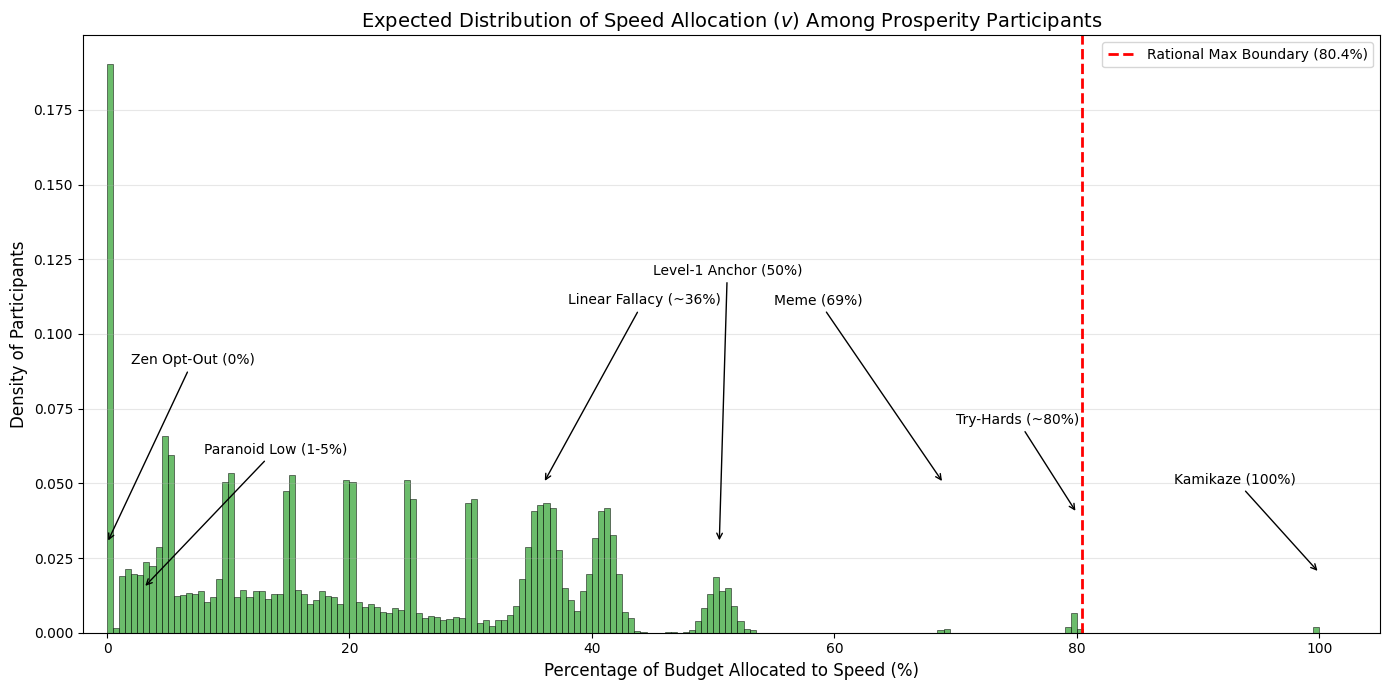

In [58]:
simulated_bids = get_expected_speed_distribution(10000)
plot_distribution(simulated_bids)